# Statlog Australian Credit

## SECCIÓN 0 — DESCRIPCIÓN DEL DATASET

Credit scoring en Australia (UCI Statlog); similar a Credit Approval.

### Tarea de machine learning
- **Tipo de tarea**: clasificación binaria
- **Variable objetivo**: Primera columna = etiqueta (0/1), última en algunas descripciones — aquí columna 0 es la etiqueta.

Las siguientes celdas cargan datos y muestran `head`, `shape`, `dtypes` y `describe`.

In [1]:
import warnings  # Avisos
warnings.filterwarnings("ignore")  # Ocultar
from pathlib import Path  # Rutas
import numpy as np  # Numerico
import pandas as pd  # Tablas
import matplotlib.pyplot as plt  # Graficos
import seaborn as sns  # Stats
from IPython.display import display  # Jupyter
from sklearn.model_selection import train_test_split  # Split
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Escalado
from sklearn.linear_model import LinearRegression, LogisticRegression  # Modelos
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score  # Metricas
ROOT_NB = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia")  # Raiz proyecto

df = pd.read_csv(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/7. Statlog (Australian Credit Approval) – UCI/statlog+australian+credit+approval/australian.dat", sep=r"\s+", header=None, engine="python")  # Regex: uno o mas espacios
display(df.head(10))  # Muestra
print(df.shape)  # Forma
print(df.dtypes)  # Tipos
display(df.describe(include="all").T)  # Stats


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
5,0,15.83,0.585,2,8,8,1.500,1,1,2,0,2,100,1,1
6,1,17.42,6.500,2,3,4,0.125,0,0,0,0,2,60,101,0
7,0,58.67,4.460,2,11,8,3.040,1,1,6,0,2,43,561,1
8,1,27.83,1.000,1,2,8,3.000,0,0,0,0,2,176,538,0
9,0,55.75,7.080,2,4,8,6.750,1,1,3,1,2,100,51,0


(690, 15)
0       int64
1     float64
2     float64
3       int64
4       int64
5       int64
6     float64
7       int64
8       int64
9       int64
10      int64
11      int64
12      int64
13      int64
14      int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
0,690.0,0.678261,0.467482,0.00,0.000,1.000,1.0000,1.00
1,690.0,31.568203,11.853273,13.75,22.670,28.625,37.7075,80.25
2,690.0,4.758725,4.978163,0.00,1.000,2.750,7.2075,28.00
3,690.0,1.766667,0.430063,1.00,2.000,2.000,2.0000,3.00
4,690.0,7.372464,3.683265,1.00,4.000,8.000,10.0000,14.00
5,690.0,4.692754,1.992316,1.00,4.000,4.000,5.0000,9.00
6,690.0,2.223406,3.346513,0.00,0.165,1.000,2.6250,28.50
7,690.0,0.523188,0.499824,0.00,0.000,1.000,1.0000,1.00
8,690.0,0.427536,0.495080,0.00,0.000,0.000,1.0000,1.00
9,690.0,2.400000,4.862940,0.00,0.000,0.000,3.0000,67.00


## SECCIÓN 1

In [2]:
df1 = df.copy()  # Copia para limpiar
print("Nulos ANTES por columna (top):\n", df1.isnull().sum().sort_values(ascending=False).head(15))  # Conteo
df1 = df1.drop_duplicates()  # Eliminar filas duplicadas
nr = df1.isnull().mean()  # Fraccion nulos
drop_null = nr[nr > 0.40].index.tolist()  # Columnas >40% nulos
print("Eliminadas por >40% nulos:", drop_null)  # Motivo: poca informacion
df1 = df1.drop(columns=drop_null, errors="ignore")  # Borrar
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()  # Numericas
cat_cols = [c for c in df1.columns if c not in num_cols]  # Categoricas
for c in num_cols:
    df1[c] = df1[c].fillna(df1[c].median())  # Mediana (robusta a outliers)
for c in cat_cols:
    if df1[c].isnull().any():
        mod = df1[c].mode()
        df1[c] = df1[c].fillna(mod.iloc[0] if len(mod) else "")  # Moda
print("Nulos DESPUES (total):", int(df1.isnull().sum().sum()))  # Debe ser 0
assert df1.isnull().sum().sum() == 0
df_clean = df1.copy()


Nulos ANTES por columna (top):
 0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
dtype: int64
Eliminadas por >40% nulos: []
Nulos DESPUES (total): 0


## SECCIÓN 2 — Primera columna = y

X.shape (690, 14) y.shape (690,)
0
1    468
0    222
Name: count, dtype: int64


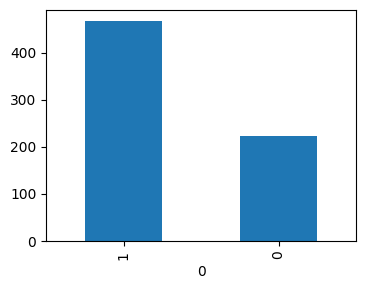

Top corr: f5     0.097009
f2     0.063528
f7     0.063256
f10    0.059901
f11    0.058595
dtype: float64


In [3]:
y = df_clean.iloc[:, 0].astype(int)  # Primera columna etiqueta
X = df_clean.iloc[:, 1:].copy()  # Resto features
X.columns = [f"f{i}" for i in range(X.shape[1])]  # Nombres genericos f0, f1, ...
print("X.shape", X.shape, "y.shape", y.shape)  # Shapes
print(y.value_counts())  # Clases
plt.figure(figsize=(4,3))  # Figura
y.value_counts().plot(kind="bar")  # Barras
plt.show()  # Grafico
num_x = X.select_dtypes(include=[np.number]).columns  # Numericas
if len(num_x) > 0:
    print("Top corr:", X[num_x].corrwith(y).abs().sort_values(ascending=False).head(5))  # Top 5


## SECCIÓN 3

In [4]:
X_enc = X.copy()  # Copia
non_num = [c for c in X_enc.columns if not pd.api.types.is_numeric_dtype(X_enc[c])]  # Categoricas
print("Categoricas (antes encoding):", non_num)  # Lista
X_enc = pd.get_dummies(X_enc, columns=non_num, drop_first=False)  # One-hot (nominal)
print("Columnas despues encoding:", X_enc.shape[1])  # Total
display(X_enc.head(5))  # Primeras filas


Categoricas (antes encoding): []
Columnas despues encoding: 14


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13
0,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


## SECCIÓN 4

In [5]:
scaler = StandardScaler()  # Escalador
X_scaled = scaler.fit_transform(X_enc)  # Ajuste global
X_scaled_df = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)  # DF
antes = X_enc.iloc[:5, :min(6, X_enc.shape[1])]  # 5 filas antes
despues = X_scaled_df.iloc[:5, :min(6, X_scaled_df.shape[1])]  # 5 filas despues
display(pd.concat([antes, despues], axis=1, keys=["ANTES","DESPUES"]))  # Comparativa


ANTES                          DESPUES                                \
      f0     f1 f2 f3 f4     f5        f0        f1        f2        f3   
0  22.08  11.46  2  4  4  1.585 -0.801052  1.347111  0.542950 -0.916282   
1  22.67   7.00  2  8  4  0.165 -0.751240  0.450548  0.542950  0.170499   
2  29.58   1.75  1  4  4  1.250 -0.167856 -0.604823 -1.783978 -0.916282   
3  21.67  11.50  1  5  3  0.000 -0.835667  1.355152 -1.783978 -0.644587   
4  20.17   8.17  2  6  4  1.960 -0.962306  0.685745  0.542950 -0.372892   

                       
         f4        f5  
0 -0.347965 -0.190906  
1 -0.347965 -0.615536  
2 -0.347965 -0.291083  
3 -0.850257 -0.664877  
4 -0.347965 -0.078768

## SECCIÓN 5

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)  # Estratificado
print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Tamano


Shapes: (552, 14) (138, 14) (552,) (138,)


## SECCIÓN 6

In [7]:
clf = LogisticRegression(max_iter=1000)  # Modelo
clf.fit(X_train, y_train)  # Entrenar
acc = accuracy_score(y_test, clf.predict(X_test))  # Accuracy
print("Accuracy:", acc)  # Resultado
score_aus = acc  # Score


Accuracy: 0.6666666666666666


## SECCIÓN 7

In [8]:
out = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/7. Statlog (Australian Credit Approval) – UCI")  # Carpeta
pd.concat([X_scaled_df, y.rename("label")], axis=1).to_csv(out / "australian_credit_clean.csv", index=False)  # Limpio
X_train.to_csv(out / "X_train.csv", index=False)  # Train
X_test.to_csv(out / "X_test.csv", index=False)  # Test
y_train.to_csv(out / "y_train.csv", index=True, header=True)  # y
y_test.to_csv(out / "y_test.csv", index=True, header=True)  # y test
print("Guardado australian_credit_clean.csv")  # Ok


Guardado australian_credit_clean.csv


## SECCIÓN 8

In [9]:
display(df_clean.head(10))  # Muestra
assert df_clean.isnull().sum().sum() == 0
print("RESUMEN Australian | Acc:", round(acc, 4))  # Resumen


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
5,0,15.83,0.585,2,8,8,1.500,1,1,2,0,2,100,1,1
6,1,17.42,6.500,2,3,4,0.125,0,0,0,0,2,60,101,0
7,0,58.67,4.460,2,11,8,3.040,1,1,6,0,2,43,561,1
8,1,27.83,1.000,1,2,8,3.000,0,0,0,0,2,176,538,0
9,0,55.75,7.080,2,4,8,6.750,1,1,3,1,2,100,51,0


RESUMEN Australian | Acc: 0.6667
